# TxCat — Robust Bank Transaction Categorization
## under Merchant, Format, and Data-Distribution Shift

**Dataset:** `DoDataThings/us-bank-transaction-categories-v2` (HuggingFace, MIT; loaded automatically)

**Canonical implementation:** `transactions.py` — this notebook executes that pipeline live.

### Central research question
> Does a transaction-category classifier learn generalizable banking language,
> or does it mainly memorize merchant identity, transaction identifiers, and
> formatting artifacts?

### Controlled benchmark
This is a **controlled synthetic bank-transaction benchmark** with realistic
statement formats (Chase ACH, PayPal, Square/Toast/Clover POS, Capital One,
Apple Card addresses, simple). Results here do **not** estimate
bank-production performance.

### Method summary
| Layer | Technique |
|---|---|
| Representation | word TF-IDF (1–2 g) · char TF-IDF (3–5 g) · sparse hybrid |
| Structured | debit/credit direction · length/digit/punctuation stats |
| Classifiers | Logistic Regression · Linear SVM · XGBoost |
| Robustness | merchant-disjoint · merchant+description-disjoint · format-disjoint · masking ablation |
| Reliability | calibration · confidence-aware selective prediction |
| Data-centric | learning curve · feature ablation · error analysis |

**Reproducibility:** `RANDOM_STATE = 42`; TF-IDF fit on train only; no test-set
calibration or threshold selection; fixed test set for learning curves.

## 1. Problem Definition

**Objective** — predict one of 17 transaction categories from a short, noisy
bank-statement description.

**Input** — transaction description + valid metadata (debit/credit direction,
detectable format family, extractable merchant).

**Output** — transaction category.  **Primary metric: Macro-F1**; secondary:
Accuracy, Weighted-F1, per-class P/R/F1.

**Experimental approach** — single-dataset, data-centric study isolating the
effect of (a) text representation, (b) structured direction, (c) merchant
identity, and (d) transaction-format artifacts on generalization.

**Design principle** — no algorithm zoo. Every experiment answers one question
tied to the central research question.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

import transactions as tx

print("module ok")

module ok


## 2. Dataset & Data Quality

**Objective** — load the canonical dataset automatically, validate the schema,
and quantify missingness, duplicates, class balance, direction, formats and
merchants.

**Method** — `transactions.load_raw_dataframe` (HuggingFace) + `inspect_schema`
+ field extraction (direction, merchant, format, city).

**Result** — counts below are computed from the loaded data (never hard-coded).

In [2]:
df = tx.load_raw_dataframe(tx.DATASET_ID)
print("rows:", len(df))
print("columns:", list(df.columns))
df.head()

2026-08-19 05:39:05 | INFO     | Loading DoDataThings/us-bank-transaction-categories-v2 …


2026-08-19 05:39:06 | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/DoDataThings/us-bank-transaction-categories-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"


2026-08-19 05:39:06 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/DoDataThings/us-bank-transaction-categories-v2/3e8d052cb7b362fb1a04b6064d2331982553ea56/README.md "HTTP/1.1 200 OK"


2026-08-19 05:39:06 | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/DoDataThings/us-bank-transaction-categories-v2/resolve/3e8d052cb7b362fb1a04b6064d2331982553ea56/us-bank-transaction-categories-v2.py "HTTP/1.1 404 Not Found"


2026-08-19 05:39:07 | INFO     | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/DoDataThings/us-bank-transaction-categories-v2/DoDataThings/us-bank-transaction-categories-v2.py "HTTP/1.1 404 Not Found"


...

2026-08-19 05:39:08 | INFO     | HTTP Request: GET https://huggingface.co/api/datasets/DoDataThings/us-bank-transaction-categories-v2/tree/3e8d052cb7b362fb1a04b6064d2331982553ea56?recursive=false&expand=false "HTTP/1.1 200 OK"


2026-08-19 05:39:09 | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/DoDataThings/us-bank-transaction-categories-v2/resolve/3e8d052cb7b362fb1a04b6064d2331982553ea56/dataset_infos.json "HTTP/1.1 404 Not Found"


2026-08-19 05:39:09 | INFO     | Loaded 68000 rows, columns=['description', 'category']


rows: 68000
columns: ['description', 'category']


,description,category
0,[debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 99...,Insurance
1,[debit] MTG PMT PENFED CU,Mortgage
2,[debit] BETMGM 147 PARK BLVD UNION CITY 94587 ...,Entertainment
3,[debit] REPUBLIC SERVICES 222 MISSION CT CHICA...,Utilities
4,[debit] PYPL*365 MARKET,Groceries


In [3]:
schema = tx.inspect_schema(df)
pd.DataFrame(schema["columns"]).assign(n_rows=schema["n_rows"])

,column,dtype,missing,missing_pct,unique,role,n_rows
0,description,object,0,0.0,45697,transaction text,68000
1,category,object,0,0.0,17,target category,68000


In [4]:
df["direction"] = df["description"].apply(tx.extract_direction)
df["merchant"] = df["description"].apply(tx.extract_merchant)
df["format"] = df["description"].apply(tx.detect_format)
df["city"] = df["description"].apply(tx.extract_city)
df["text_basic"] = df["description"].apply(tx.normalize_basic)
df["text_structured"] = df["description"].apply(tx.normalize_structured)

summary = {
    "rows": int(len(df)),
    "categories": int(df["category"].nunique()),
    "merchants": int(df["merchant"].nunique()),
    "cities": int(df["city"].nunique()),
    "formats": {k: int(v) for k, v in df["format"].value_counts().items()},
    "direction": {k: int(v) for k, v in df["direction"].value_counts().items()},
    "duplicate_descriptions": int(df["description"].duplicated().sum()),
    "duplicate_full_rows": int(df.duplicated().sum()),
    "class_distribution": {k: int(v) for k, v in df["category"].value_counts().items()},
}
Path("out").mkdir(exist_ok=True)
tx.write_json(summary, Path("out") / "dataset_summary.json")
print(json.dumps(summary, indent=2))

{
  "rows": 68000,
  "categories": 17,
  "merchants": 12918,
  "cities": 35,
  "formats": {
    "simple": 45386,
    "ach": 8272,
    "paypal": 5732,
    "address": 4670,
    "capital_one": 2791,
    "pos": 1149
  },
  "direction": {
    "debit": 60007,
    "credit": 7993
  },
  "duplicate_descriptions": 22303,
  "duplicate_full_rows": 22298,
  "class_distribution": {
    "Insurance": 4000,
    "Mortgage": 4000,
    "Entertainment": 4000,
    "Utilities": 4000,
    "Groceries": 4000,
    "Personal Care": 4000,
    "Shopping": 4000,
    "Subscription": 4000,
    "Healthcare": 4000,
    "Rent": 4000,
    "Fees": 4000,
    "Income": 4000,
    "Transportation": 4000,
    "Education": 4000,
    "Restaurants": 4000,
    "Transfer": 4000,
    "Travel": 4000
  }
}


In [5]:
print("Class distribution (count | %):")
dist = df["category"].value_counts()
tab = pd.DataFrame({"count": dist, "percent": (dist / len(df) * 100).round(2)})
tab

Class distribution (count | %):


,count,percent
category,,
Insurance,4000,5.88
Mortgage,4000,5.88
Entertainment,4000,5.88
Utilities,4000,5.88
Groceries,4000,5.88
Personal Care,4000,5.88
Shopping,4000,5.88
Subscription,4000,5.88
Healthcare,4000,5.88


In [6]:
print("Direction distribution:")
print(df["direction"].value_counts())
print()
print("Transaction-format families detected:")
print(df["format"].value_counts().to_string())
print()
print(f"Duplicate descriptions: {summary['duplicate_descriptions']:,} "
      f"({summary['duplicate_descriptions'] / len(df):.1%})")
print(f"Duplicate full rows:    {summary['duplicate_full_rows']:,}")

Direction distribution:
direction
debit     60007
credit     7993
Name: count, dtype: int64

Transaction-format families detected:
format
simple         45386
ach             8272
paypal          5732
address         4670
capital_one     2791
pos             1149

Duplicate descriptions: 22,303 (32.8%)
Duplicate full rows:    22,298


### 2.1 Duplicate-description audit

**Research question** — the dataset contains substantial repeated
descriptions.  Duplicates are *not* removed: they are part of the scientific
investigation.  If a random split lets the same exact description appear in
both train and test, the test can be answered partly by memorization.

**Method** — count exact duplicates, duplicates spanning multiple categories
or merchants, and the exact-description overlap between random-split train
and test.

**Interpretation** — a high train/test description overlap explains why the
random split can be unusually easy relative to the disjoint benchmarks.

In [7]:
dup_audit = tx.duplicate_audit(df, train_df=None, test_df=None)
print(json.dumps(dup_audit, indent=2))

{
  "n_unique_descriptions": 45697,
  "n_duplicate_descriptions": 5177,
  "n_duplicate_rows": 22303,
  "n_duplicate_full_rows": 22298,
  "max_occurrences_of_one_description": 445,
  "dup_descs_spanning_multiple_categories": 5,
  "dup_descs_spanning_multiple_merchants": 0
}


In [8]:
# description overlap between the RANDOM-split train and test
from sklearn.model_selection import train_test_split
_r_tr, _r_te = tx.make_splits(df, test_size=0.2, seed=42)
dup_audit_random = tx.duplicate_audit(df, _r_tr, _r_te)
print("Random-split description overlap:",
      f"{dup_audit_random['random_split_desc_overlap']:,} descriptions "
      f"({dup_audit_random['random_split_test_desc_share_seen_in_train']:.1%} of test rows)")
tx.write_json(dup_audit_random, Path("out") / "dataset_duplicate_audit.json")
print("saved out/dataset_duplicate_audit.json")

Random-split description overlap: 2,664 descriptions (24.5% of test rows)
saved out/dataset_duplicate_audit.json


## 3. Exploratory Data Analysis

**Objective** — understand the surface structure of the descriptions and which
surface cues correlate with categories.  Every plot motivates a later
experiment.

**Method** — description length/digit/punct profiles, category × direction,
merchant long tail, format × category overlap.

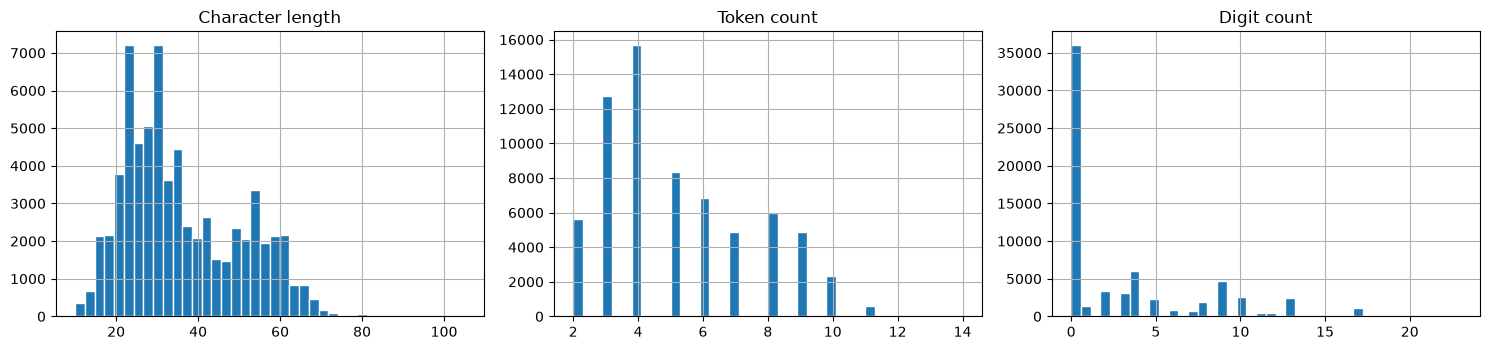

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
feats = tx.structural_features(df)
feats[["char_count", "token_count", "digit_count"]].hist(
    bins=40, ax=axes, edgecolor="white"
)
axes[0].set_title("Character length"); axes[1].set_title("Token count"); axes[2].set_title("Digit count")
plt.tight_layout(); plt.show()

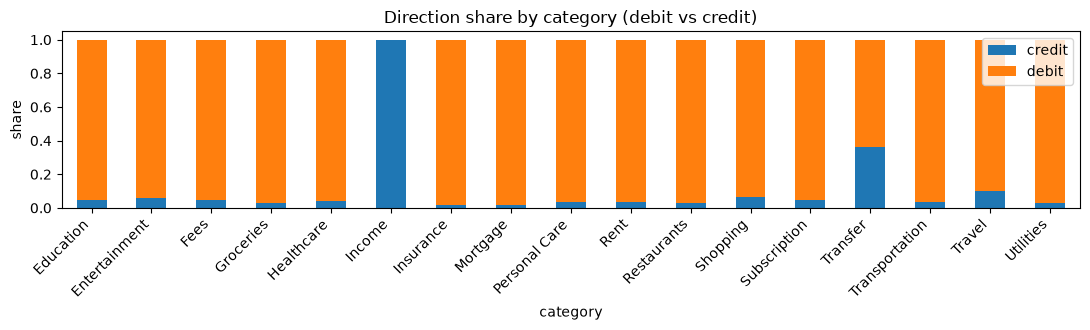

In [10]:
# category × direction heatmap
ct = pd.crosstab(df["category"], df["direction"], normalize="index")
ct.plot(kind="bar", figsize=(11, 3.4), stacked=True)
plt.title("Direction share by category (debit vs credit)")
plt.ylabel("share"); plt.xticks(rotation=45, ha="right"); plt.legend(loc="upper right")
plt.tight_layout(); plt.show()

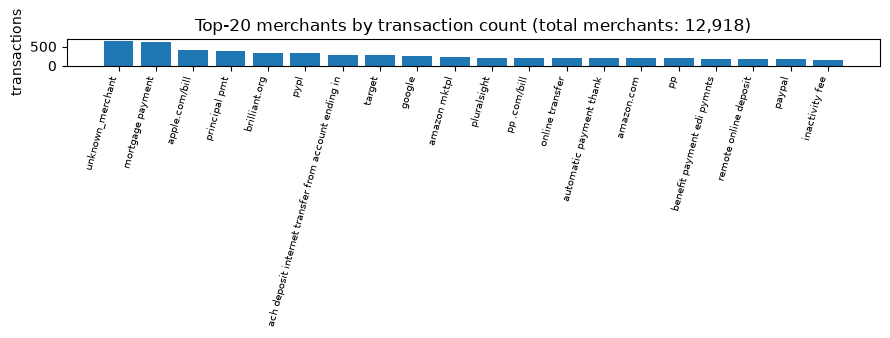

Merchant long tail: share of merchants with a single transaction = 61.1%


In [11]:
# merchant long tail
mc = df["merchant"].value_counts()
top = mc.head(20)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(range(len(top)), top.values)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=75, ha="right", fontsize=7)
ax.set_ylabel("transactions")
ax.set_title(f"Top-20 merchants by transaction count (total merchants: {df['merchant'].nunique():,})")
plt.tight_layout(); plt.show()

print("Merchant long tail: share of merchants with a single transaction =",
      f"{(mc == 1).mean():.1%}")

In [12]:
# format × category concentration (which categories rely on which formats)
fmt_cat = pd.crosstab(df["format"], df["category"], normalize="index")
print(fmt_cat.round(3).head(10).to_string())

category     Education  Entertainment   Fees  Groceries  Healthcare  Income  Insurance  Mortgage  Personal Care   Rent  Restaurants  Shopping  Subscription  Transfer  Transportation  Travel  Utilities
format                                                                                                                                                                                                  
ach              0.000          0.000  0.000      0.000       0.013   0.168      0.199     0.148          0.000  0.189        0.000     0.000         0.000     0.089           0.008   0.000      0.186
address          0.061          0.090  0.000      0.097       0.057   0.000      0.149     0.000          0.097  0.000        0.100     0.055         0.085     0.000           0.052   0.074      0.083
capital_one      0.072          0.088  0.000      0.000       0.038   0.000      0.000     0.063          0.118  0.191        0.000     0.000         0.000     0.050           0.038   0.101      0

In [13]:
# sample descriptions per category
for c in ["Groceries", "Income", "Transfer", "Utilities"]:
    print(f"== {c} ==")
    for d in df[df.category == c].description.head(3):
        print("   ", d)
    print()

== Groceries ==
    [debit] PYPL*365 MARKET
    [debit] PUBLIX 7860 UNIVERSITY LN OAKLAND 94601-4574CA USA
    [debit] GROCOUTLT #47001 HOUSTON

== Income ==
    [credit] US GOVERNMENT DIR DEP PPD ID: 547185326
    [credit] Payment Refund: ASOS
    [credit] SALESFORCE PAYROLL

== Transfer ==
    [debit] MERRILL LYNCH INVESTMENTS MONEYLINE
    [debit] MONTHLY INSTALLMENTS (11 OF 12)
    [debit] MONTHLY INSTALLMENTS (10 OF 24)

== Utilities ==
    [debit] REPUBLIC SERVICES 222 MISSION CT CHICAGO60601 IL USA
    [debit] MUNICIPAL WATER UTIL PMT WEB ID: 1P3K5KBY
    [debit] republic services 1128 main st raleigh 27601-7390nc usa



## 4. Transaction Text Normalization

**Objective** — determine whether arbitrary instance identifiers (order IDs,
reference codes, store numbers) hurt generalization by letting the model
memorize instance-level noise.

**Method** — three controlled representations:

- **A. Raw / minimal** — direction tag stripped, whitespace collapsed.
- **B. Standard normalization** — lowercased, collapsed whitespace (structure preserved).
- **C. Structure-aware** — numeric order/ref/store tokens replaced with
  `<REF>` / `<STORE>` / `<NUM>` placeholders (long numeric IDs, order IDs,
  reference codes, store numbers).  Stable merchant identity is *not* erased
  except where the experiment explicitly masks it (§12).

**Result** — examples of each representation.

In [14]:
samples = df["description"].head(6).tolist()
for s in samples:
    print("RAW :", s)
    print("BAS :", tx.normalize_basic(s))
    print("STR :", tx.normalize_structured(s))
    print()

RAW : [debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 9901629141
BAS : northwestern mutualeft pymt ppd id: 9901629141
STR : northwestern mutualeft pymt <ref>

RAW : [debit] MTG PMT PENFED CU
BAS : mtg pmt penfed cu
STR : mtg pmt penfed cu

RAW : [debit] BETMGM 147 PARK BLVD UNION CITY 94587 CA USA
BAS : betmgm 147 park blvd union city 94587 ca usa
STR : betmgm 147 park blvd union city <num> ca usa

RAW : [debit] REPUBLIC SERVICES 222 MISSION CT CHICAGO60601 IL USA
BAS : republic services 222 mission ct chicago60601 il usa
STR : republic services 222 mission ct chicago60601 il usa

RAW : [debit] PYPL*365 MARKET
BAS : pypl*365 market
STR : pypl <ref> market

RAW : [debit] PUBLIX 7860 UNIVERSITY LN OAKLAND 94601-4574CA USA
BAS : publix 7860 university ln oakland 94601-4574ca usa
STR : publix <num> university ln oakland <num> -4574ca usa



In [15]:
df["text_raw"] = df["description"].apply(tx.normalize_raw)
df["text_basic"] = df["description"].apply(tx.normalize_basic)
df["text_structured"] = df["description"].apply(tx.normalize_structured)

# how much token mass does structure-masking remove?
raw_tokens = df["text_basic"].str.split().str.len()
masked_tokens = df["text_structured"].str.split().str.len()
print(f"Mean tokens  basic: {raw_tokens.mean():.2f}")
print(f"Mean tokens  structured: {masked_tokens.mean():.2f}")
print(f"Mean tokens  removed by masking: {(raw_tokens - masked_tokens).mean():.2f}")

Mean tokens  basic: 4.18
Mean tokens  structured: 3.99
Mean tokens  removed by masking: 0.19


## 5. Evaluation Protocol

**Objective** — define a fair, leak-free evaluation protocol.

**Method**

1. Stratified **random split** (80/20) for the standard in-distribution
   benchmark (labelled as potentially merchant-overlapping).
2. **Merchant-disjoint split** (grouped by canonical merchant key, zero
   overlap) — the primary generalization benchmark.
3. **Strict split** (merchant-disjoint + exact-description-disjoint) — §14.
4. TF-IDF fit on the **training split only**; test set untouched.
5. Fixed `RANDOM_STATE = 42`; identical representations and hyperparameters
   across regimes.
6. Metrics: Accuracy, **Macro-F1 (primary)**, Weighted-F1, per-class F1.

**Caveat on merchant identity.** `merchant` is a heuristic key extracted by
`transactions.extract_merchant` (regex wrapper-stripping + head truncation).
The canonicalization is audited in §11.1; the disjoint benchmarks are
disjoint *by canonical key* and are verified to have zero overlap.

In [16]:
train_df, test_df = tx.make_splits(df, test_size=0.2, seed=42)
print(f"Random split: train {len(train_df):,} / test {len(test_df):,}")

g_train, g_test, split_info = tx.merchant_disjoint_split(df, test_size=0.2, seed=42)
print(f"Merchant-disjoint: train {len(g_train):,} / test {len(g_test):,}")
print("Canonical merchant overlap (must be 0):", split_info["merchant_overlap"])

overlap = tx.merchant_overlap_fraction(train_df, test_df)
print(f"Random split merchant overlap (test rows sharing a merchant with train): {overlap:.1%}")
print(f"Unique canonical merchants: {df['merchant'].nunique():,}")

Random split: train 54,400 / test 13,600
Merchant-disjoint: train 52,686 / test 15,314
Canonical merchant overlap (must be 0): 0
Random split merchant overlap (test rows sharing a merchant with train): 87.7%
Unique canonical merchants: 12,918


## 6. Word-Level TF-IDF

**Objective** — establish the word-level baseline on the standard random
split with two linear classifiers.

**Method** — `TfidfVectorizer(analyzer="word", ngram_range=(1,2),
sublinear_tf=True)`, 15,000 features, fit on train only; multinomial
Logistic Regression and Linear SVM.

**Result** — baseline metrics.

In [17]:
wv = tx.fit_word_tfidf(train_df["description"], max_features=15_000)
Xtr_w, Xte_w = tx.vectorize_pair(wv, train_df["description"], test_df["description"])
print("Train:", Xtr_w.shape, " Test:", Xte_w.shape)

Train: (54400, 13042)  Test: (13600, 13042)


In [18]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_w, train_df["category"].values
)
base_metrics = tx.evaluate_model(
    baseline, Xte_w, test_df["category"].values,
    sorted(train_df["category"].unique()), "baseline word-LR",
)
print("Word + LogisticRegression  | Acc:", base_metrics["accuracy"],
      "| Macro-F1:", base_metrics["macro_f1"])

2026-08-19 05:39:17 | INFO     | baseline word-LR — Acc 0.9946  Macro-F1 0.9946  W-F1 0.9946


Word + LogisticRegression  | Acc: 0.9946 | Macro-F1: 0.9946


In [19]:
from sklearn.svm import LinearSVC

word_svc = LinearSVC(max_iter=8000, random_state=42).fit(
    Xtr_w, train_df["category"].values
)
word_svc_metrics = tx.evaluate_model(
    word_svc, Xte_w, test_df["category"].values,
    sorted(train_df["category"].unique()), "baseline word-LinearSVM",
)
print("Word + LinearSVM           | Acc:", word_svc_metrics["accuracy"],
      "| Macro-F1:", word_svc_metrics["macro_f1"])

2026-08-19 05:39:20 | INFO     | baseline word-LinearSVM — Acc 0.9976  Macro-F1 0.9976  W-F1 0.9976


Word + LinearSVM           | Acc: 0.9976 | Macro-F1: 0.9976


## 7. Character-Level TF-IDF

**Objective** — test whether character n-grams add signal beyond words.

**Rationale** — transaction descriptions are full of prefixes, abbreviations,
compressed merchant names, IDs, and spacing quirks that word tokenization
destroys.

**Method** — `TfidfVectorizer(analyzer="char", ngram_range=(3,5))`, 20,000
features, same split and classifiers as §6.

In [20]:
cv = tx.fit_char_tfidf(train_df["description"], max_features=20_000)
Xtr_c, Xte_c = tx.vectorize_pair(cv, train_df["description"], test_df["description"])
print("Train:", Xtr_c.shape, " Test:", Xte_c.shape)

Train: (54400, 20000)  Test: (13600, 20000)


In [21]:
char_lr = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_c, train_df["category"].values
)
char_metrics = tx.evaluate_model(
    char_lr, Xte_c, test_df["category"].values,
    sorted(train_df["category"].unique()), "char-LR",
)
print("Char + LogisticRegression  | Acc:", char_metrics["accuracy"],
      "| Macro-F1:", char_metrics["macro_f1"])

2026-08-19 05:39:30 | INFO     | char-LR — Acc 0.9918  Macro-F1 0.9917  W-F1 0.9917


Char + LogisticRegression  | Acc: 0.9918 | Macro-F1: 0.9917


## 8. Hybrid Text Representation

**Objective** — combine word + character evidence.

**Method** — `scipy.sparse.hstack` of the word and char TF-IDF matrices (no
densification), same classifiers, same split.

**Result** — hybrid vs word vs char isolates the representation effect.

In [22]:
from scipy.sparse import hstack

Xtr_h = hstack([Xtr_w, Xtr_c], format="csr")
Xte_h = hstack([Xte_w, Xte_c], format="csr")
print("Hybrid:", Xtr_h.shape, Xte_h.shape)

Hybrid: (54400, 33042) (13600, 33042)


In [23]:
hybrid_lr = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_h, train_df["category"].values
)
hybrid_metrics = tx.evaluate_model(
    hybrid_lr, Xte_h, test_df["category"].values,
    sorted(train_df["category"].unique()), "hybrid-LR",
)
print("Hybrid + LogisticRegression | Acc:", hybrid_metrics["accuracy"],
      "| Macro-F1:", hybrid_metrics["macro_f1"])

2026-08-19 05:39:37 | INFO     | hybrid-LR — Acc 0.9965  Macro-F1 0.9965  W-F1 0.9965


Hybrid + LogisticRegression | Acc: 0.9965 | Macro-F1: 0.9965


In [24]:
rep_compare = pd.DataFrame({
    "Representation": ["Word", "Character", "Word + Character"],
    "Accuracy": [base_metrics["accuracy"], char_metrics["accuracy"], hybrid_metrics["accuracy"]],
    "Macro-F1": [base_metrics["macro_f1"], char_metrics["macro_f1"], hybrid_metrics["macro_f1"]],
    "Weighted-F1": [base_metrics["weighted_f1"], char_metrics["weighted_f1"], hybrid_metrics["weighted_f1"]],
})
rep_compare

,Representation,Accuracy,Macro-F1,Weighted-F1
0,Word,0.9946,0.9946,0.9946
1,Character,0.9918,0.9917,0.9917
2,Word + Character,0.9965,0.9965,0.9965


## 9. Structured Feature Engineering

**Objective** — build lightweight text-structure features from fields actually
present in the data, and measure their incremental value.

**Method** — per-transaction structural statistics (character/token/digit
counts, digit ratio, punctuation count, alphabetic/numeric token counts) and
debit/credit direction one-hots, stacked sparsely on the hybrid text matrix.

**Result** — feature inventory, then the §9.1 ablation.

In [25]:
feat = tx.structural_features(df)
print("Structural feature matrix shape:", feat.shape)
feat.head()

Structural feature matrix shape: (68000, 7)


,char_count,token_count,digit_count,digit_ratio,punct_count,alpha_token_count,numeric_token_count
0,54,7,10,0.185185,3,6,1
1,25,5,0,0.000000,2,5,0
2,52,10,8,0.153846,2,8,2
3,60,9,8,0.133333,2,7,1
4,23,3,3,0.130435,3,3,1


In [26]:
dir_oh = tx.direction_onehot(df)
print("Direction one-hot shape:", dir_oh.shape)
dir_oh.head()

Direction one-hot shape: (68000, 2)


,dir_credit,dir_debit
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


### 9.1 Feature ablation

**Research question** — how much does each feature family contribute?

**Method** — same random split, same LogisticRegression classifier, five
controlled feature sets: word / char / word+char / +direction / +structural.

**Result** — ablation table (programmatic).

In [27]:
abl = tx.feature_ablation(train_df, test_df, seed=42)
abl_df = pd.DataFrame(abl).T.reset_index().rename(columns={"index": "Feature set"})
abl_df

2026-08-19 05:39:40 | INFO     | logreg · word — Acc 0.9946  Macro-F1 0.9946  W-F1 0.9946


2026-08-19 05:39:51 | INFO     | logreg · char — Acc 0.9918  Macro-F1 0.9917  W-F1 0.9917


2026-08-19 05:40:02 | INFO     | logreg · hybrid — Acc 0.9965  Macro-F1 0.9965  W-F1 0.9965


2026-08-19 05:40:15 | INFO     | logreg · hybrid — Acc 0.9967  Macro-F1 0.9967  W-F1 0.9967


2026-08-19 05:46:55 | INFO     | logreg · hybrid — Acc 0.9960  Macro-F1 0.9959  W-F1 0.9959


,Feature set,accuracy,macro_f1,weighted_f1
0,word,0.9946,0.9946,0.9946
1,char,0.9918,0.9917,0.9917
2,word+char,0.9965,0.9965,0.9965
3,word+char+dir,0.9967,0.9967,0.9967
4,word+char+dir+struct,0.9960,0.9959,0.9959


In [28]:
tx.write_json(abl, Path("out") / "feature_ablation.json")
print("saved out/feature_ablation.json")

saved out/feature_ablation.json


## 10. Model Comparison

**Objective** — compare the three classifiers on the *same* representation,
split and metrics: Logistic Regression, Linear SVM, XGBoost.

**Method** — hybrid word+char+direction features (the §9.1 ablation winner;
structural statistics are omitted because they did not improve Macro-F1);
small, sensible hyperparameters; identical evaluation (no
tuned-vs-untuned comparisons).

**Result** — random-split comparison (in-distribution reference only; final
selection uses the merchant-disjoint benchmark in §11).

In [29]:
labels = sorted(train_df["category"].unique())
Xtr_full = tx.build_feature_matrix(Xtr_h, train_df, use_direction=True, use_structural=False)
Xte_full = tx.build_feature_matrix(Xte_h, test_df, use_direction=True, use_structural=False)
print("Full feature matrix:", Xtr_full.shape)

Full feature matrix: (54400, 33044)


In [30]:
models = {}
metrics = {}

models["logreg"] = LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42).fit(
    Xtr_full, train_df["category"].values
)
metrics["logreg"] = tx.evaluate_model(
    models["logreg"], Xte_full, test_df["category"].values, labels, "LogReg · full"
)

models["linearsvc"] = LinearSVC(max_iter=8000, random_state=42).fit(
    Xtr_full, train_df["category"].values
)
metrics["linearsvc"] = tx.evaluate_model(
    models["linearsvc"], Xte_full, test_df["category"].values, labels, "LinearSVC · full"
)

2026-08-19 05:47:04 | INFO     | LogReg · full — Acc 0.9967  Macro-F1 0.9967  W-F1 0.9967


2026-08-19 05:47:31 | INFO     | LinearSVC · full — Acc 0.9988  Macro-F1 0.9987  W-F1 0.9987


In [31]:
# XGBoost — deliberately bounded capacity
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder().fit(labels)
y_enc = le.transform(train_df["category"].values)

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(labels), n_estimators=150,
    max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method="hist", verbosity=0,
).fit(Xtr_full, y_enc)
xgb_wrap = tx.XGBStringWrapper(xgb_model, le)
metrics["xgboost"] = tx.evaluate_model(
    xgb_wrap, Xte_full, test_df["category"].values, labels, "XGBoost · full"
)
models["xgboost"] = xgb_wrap

2026-08-19 05:58:27 | INFO     | XGBoost · full — Acc 0.9880  Macro-F1 0.9879  W-F1 0.9879


In [32]:
model_compare = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "XGBoost"],
    "Accuracy": [metrics["logreg"]["accuracy"], metrics["linearsvc"]["accuracy"], metrics["xgboost"]["accuracy"]],
    "Macro-F1": [metrics["logreg"]["macro_f1"], metrics["linearsvc"]["macro_f1"], metrics["xgboost"]["macro_f1"]],
    "Weighted-F1": [metrics["logreg"]["weighted_f1"], metrics["linearsvc"]["weighted_f1"], metrics["xgboost"]["weighted_f1"]],
})
model_compare

,Model,Accuracy,Macro-F1,Weighted-F1
0,Logistic Regression,0.9967,0.9967,0.9967
1,Linear SVM,0.9988,0.9987,0.9987
2,XGBoost,0.9880,0.9879,0.9879


In [33]:
tx.write_json({k: v for k, v in metrics.items()}, Path("out") / "classification_metrics.json")
print("saved out/classification_metrics.json")

saved out/classification_metrics.json


## 11. Merchant-Disjoint Generalization (core experiment)

**Objective** — does the model generalize to merchants it has never seen, or
does it memorize merchant identity?

**Method** — grouped split by canonical merchant key with **zero overlap**
(verified); identical features, classifiers and hyperparameters as §10.

**Result** — the performance gap random → merchant-disjoint is the primary
evidence about memorization vs. learning.

### 11.1 Merchant canonicalization audit

**Research question** — is the merchant-disjoint benchmark trustworthy?  The
benchmark is only meaningful if merchant extraction is correct.

**Method** — audit the extraction: distinct raw descriptions → canonical
merchant keys; alias groups (several raw forms, one canonical); rule evidence
for store numbers, order IDs, provider prefixes, US-address blocks and ACH
reference IDs.  No semantic mappings are invented — every example is from the
data.

In [34]:
audit = tx.canonicalization_audit(df, n_merchants=6, n_examples=2)
print(f"unique raw descriptions: {audit['n_unique_raw_descriptions']:,}")
print(f"unique canonical merchants: {audit['n_unique_canonical_merchants']:,}")
print(f"alias groups (>=2 raw forms -> one canonical): {audit['n_merchant_alias_groups']:,}")
print()
print("Example alias merges (raw descriptions -> canonical merchant):")
for g in audit["top_alias_groups"]:
    print(f"  [{g['canonical']}] ({g['n_raw_forms']} raw forms)")
    for r in g["raw_examples"]:
        print(f"     - {r}")

unique raw descriptions: 45,697
unique canonical merchants: 12,918
alias groups (>=2 raw forms -> one canonical): 4,131

Example alias merges (raw descriptions -> canonical merchant):
  [apple.com/bill] (417 raw forms)
     - [debit] APPLE.COM/BILL 2773 UNIVERSITY ST NEWARK 07101-4829NJ USA
     - [debit] Apple.com/bill 5846 Main Ln San Francisco 94102-2013ca Usa
  [target] (267 raw forms)
     - [debit] TARGET 15793731
     - [debit] target 97040368
  [ach deposit internet transfer from account ending in] (262 raw forms)
     - [credit] ACH DEPOSIT INTERNET TRANSFER FROM ACCOUNT ENDING IN 2147
     - [credit] ACH DEPOSIT INTERNET TRANSFER FROM ACCOUNT ENDING IN 1892
  [unknown_merchant] (235 raw forms)
     - [debit] MONTHLY INSTALLMENTS (11 OF 12)
     - [debit] MONTHLY INSTALLMENTS (10 OF 24)
  [pypl] (235 raw forms)
     - [debit] PYPL*CODECADEMY
     - [debit] PYPL*YMCA
  [amazon mktpl] (219 raw forms)
     - [debit] AMAZON MKTPL*70K72WQH
     - [debit] AMAZON MKTPL*XR5PYBM1FA


In [35]:
print("Rule evidence (representative extractions):")
for rule, exs in audit["rule_evidence"].items():
    print(f"  {rule}: {len(exs)} example(s)")
    for e in exs[:1]:
        print(f"     raw: {e['raw']}")
        print(f"     ->   {e['canonical_merchant']}")

Rule evidence (representative extractions):
  store number (#123): 2 example(s)
     raw: [debit] WAL-MART #0006
     ->   wal-mart
  order id (*ABC): 2 example(s)
     raw: [debit] PYPL*365 MARKET
     ->   pypl market
  provider prefix (SQ*/PP*/PYPL*/TST*/CLV*): 0 example(s)
  US address block (ZIP ST USA): 2 example(s)
     raw: [debit] BETMGM 147 PARK BLVD UNION CITY 94587 CA USA
     ->   betmgm
  ACH reference (PPD/WEB ID): 2 example(s)
     raw: [debit] NORTHWESTERN MUTUALEFT PYMT PPD ID: 9901629141
     ->   northwestern mutualeft pymt


### 11.2 Canonical-overlap verification

The disjoint split is verified on the **canonical** merchant key (stronger
than raw-string checks): train and test share no canonical merchant.

In [36]:
g_train, g_test, split_info = tx.merchant_disjoint_split(df, test_size=0.2, seed=42)
print("Canonical merchant overlap (must be 0):", split_info["merchant_overlap"])
assert split_info["merchant_overlap"] == 0
print(f"train {len(g_train):,} / test {len(g_test):,}")

Canonical merchant overlap (must be 0): 0
train 52,686 / test 15,314


In [37]:
g_labels = sorted(g_train["category"].unique())

gwv = tx.fit_word_tfidf(g_train["description"], max_features=15_000)
gcv = tx.fit_char_tfidf(g_train["description"], max_features=20_000)
gXw_tr, gXw_te = tx.vectorize_pair(gwv, g_train["description"], g_test["description"])
gXc_tr, gXc_te = tx.vectorize_pair(gcv, g_train["description"], g_test["description"])
gX_tr = hstack([gXw_tr, gXc_tr], format="csr")
gX_te = hstack([gXw_te, gXc_te], format="csr")
# representation = ablation winner (§9.1): word+char+direction; structural
# statistics are omitted (they did not improve Macro-F1)
gX_tr = tx.build_feature_matrix(gX_tr, g_train, use_direction=True, use_structural=False)
gX_te = tx.build_feature_matrix(gX_te, g_test, use_direction=True, use_structural=False)

gen_metrics = {}
for name, mk in [
    ("logreg", lambda: LogisticRegression(max_iter=8000, solver="lbfgs", random_state=42)),
    ("linearsvc", lambda: LinearSVC(max_iter=8000, random_state=42)),
]:
    m = mk().fit(gX_tr, g_train["category"].values)
    gen_metrics[name] = tx.evaluate_model(m, gX_te, g_test["category"].values, g_labels, f"{name} · merchant-disjoint")

2026-08-19 05:58:42 | INFO     | logreg · merchant-disjoint — Acc 0.9477  Macro-F1 0.9516  W-F1 0.9482


2026-08-19 05:59:13 | INFO     | linearsvc · merchant-disjoint — Acc 0.9547  Macro-F1 0.9588  W-F1 0.9550


In [38]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
g_le = LabelEncoder().fit(g_labels)
g_yenc = g_le.transform(g_train["category"].values)
gx = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(g_labels), n_estimators=150,
    max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method="hist", verbosity=0,
).fit(gX_tr, g_yenc)
gen_metrics["xgboost"] = tx.evaluate_model(
    tx.XGBStringWrapper(gx, g_le), gX_te, g_test["category"].values, g_labels, "xgboost · merchant-disjoint"
)

2026-08-19 06:09:32 | INFO     | xgboost · merchant-disjoint — Acc 0.8691  Macro-F1 0.8661  W-F1 0.8704


In [39]:
gen_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "XGBoost"],
    "Random Macro-F1": [metrics["logreg"]["macro_f1"], metrics["linearsvc"]["macro_f1"], metrics["xgboost"]["macro_f1"]],
    "Merchant-disjoint Macro-F1": [gen_metrics["logreg"]["macro_f1"], gen_metrics["linearsvc"]["macro_f1"], gen_metrics["xgboost"]["macro_f1"]],
})
gen_df["Δ Macro-F1"] = (gen_df["Merchant-disjoint Macro-F1"] - gen_df["Random Macro-F1"]).round(4)
gen_df["Relative drop %"] = (-gen_df["Δ Macro-F1"] / gen_df["Random Macro-F1"] * 100).round(1)
gen_df

,Model,Random Macro-F1,Merchant-disjoint Macro-F1,Δ Macro-F1,Relative drop %
0,Logistic Regression,0.9967,0.9516,-0.0451,4.5
1,Linear SVM,0.9987,0.9588,-0.0399,4.0
2,XGBoost,0.9879,0.8661,-0.1218,12.3


In [40]:
gen_out = {
    "models": gen_metrics,
    "random_split_merchant_overlap_fraction": round(tx.merchant_overlap_fraction(train_df, test_df), 4),
    "merchant_disjoint_split": split_info,
}
tx.write_json(gen_out, Path("out") / "generalization_metrics.json")
print("saved out/generalization_metrics.json")

saved out/generalization_metrics.json


In [41]:
# model family selection: best by MERCHANT-DISJOINT Macro-F1 (spec §16)
final_family = max(gen_metrics, key=lambda k: gen_metrics[k]["macro_f1"])
print(f"Final model family: {final_family} "
      f"(merchant-disjoint Macro-F1 {gen_metrics[final_family]['macro_f1']:.4f})")

Final model family: linearsvc (merchant-disjoint Macro-F1 0.9588)


## 12. Merchant Memorization Ablation

**Research question** — how much of the merchant-disjoint performance rests on
merchant identity versus generalizable transaction language?

**Method** — controlled masking ablation on the merchant-disjoint split
(span-based masking preserves linguistic context; this is *not* deleting the
description):

| condition | description fed to the model |
|---|---|
| A. Full | normalized text, untouched |
| B. Merchant masked | merchant span replaced by `<merchant>` |
| C. IDs masked | structure-aware normalization (`<REF>`/`<STORE>`/`<NUM>`) |
| D. Merchant + IDs masked | both |

**Interpretation** — the gap between Full and Merchant-masked is evidence of
merchant dependence.  This is a **controlled memorization ablation**, not a
causal attribution.

In [42]:
mem_abl = tx.merchant_ablation(df, seed=42)
mem_abl_df = pd.DataFrame(mem_abl).T.rename(columns={"accuracy": "Accuracy", "macro_f1": "Macro-F1"})
mem_abl_df

2026-08-19 06:09:37 | INFO     | ablation::full — Acc 0.9429  Macro-F1 0.9440  W-F1 0.9427


2026-08-19 06:09:40 | INFO     | ablation::merchant_masked — Acc 0.3157  Macro-F1 0.3556  W-F1 0.3444


2026-08-19 06:09:43 | INFO     | ablation::ids_masked — Acc 0.9071  Macro-F1 0.9097  W-F1 0.9088


2026-08-19 06:09:45 | INFO     | ablation::merchant_ids_masked — Acc 0.2797  Macro-F1 0.3027  W-F1 0.2899


,Accuracy,Macro-F1
full,0.9429,0.9440
merchant_masked,0.3157,0.3556
ids_masked,0.9071,0.9097
merchant_ids_masked,0.2797,0.3027


In [43]:
tx.write_json(mem_abl, Path("out") / "merchant_ablation.json")
print("saved out/merchant_ablation.json")
gap = mem_abl["full"]["macro_f1"] - mem_abl["merchant_masked"]["macro_f1"]
print(f"Full minus Merchant-masked Macro-F1: {gap:.4f}  <- merchant dependence")

saved out/merchant_ablation.json
Full minus Merchant-masked Macro-F1: 0.5884  <- merchant dependence


## 13. Transaction-Format Generalization

**Objective** — can the model classify transactions whose description format
it never saw at training time?

**Method** — detect format families (ach, paypal, pos, capital_one, address,
simple).  Train on all formats except one; test on the held-out format after
dropping held-out rows whose merchant identity appears in training (isolates
format transfer from merchant memorization).  Same features/model.

**Category-support check** — before interpreting a low score, we check whether
the held-out format's categories are absent/nearly absent from training
(label-support mismatch) — separating *representation failure* from
*support mismatch*.

In [44]:
fmt_eval = {}
for fmt in sorted(df["format"].unique()):
    fmt_eval[fmt] = tx.format_disjoint_eval(df, fmt, min_examples=500, seed=42)
fmt_eval

2026-08-19 06:10:01 | INFO     | logreg · hybrid — Acc 0.9402  Macro-F1 0.4411  W-F1 0.9490


2026-08-19 06:10:17 | INFO     | logreg · hybrid — Acc 0.9283  Macro-F1 0.1633  W-F1 0.9531


2026-08-19 06:10:32 | INFO     | logreg · hybrid — Acc 0.9862  Macro-F1 0.6983  W-F1 0.9899


2026-08-19 06:10:48 | INFO     | logreg · hybrid — Acc 0.6212  Macro-F1 0.0772  W-F1 0.7171


2026-08-19 06:10:56 | INFO     | logreg · hybrid — Acc 0.5780  Macro-F1 0.6328  W-F1 0.6538


{'ach': {'skipped': False,
  'holdout_format': 'ach',
  'merchant_disjoint': True,
  'excluded_by_merchant_overlap': 1444,
  'train_size': 59728,
  'test_size': 6828,
  'train_categories': 17,
  'test_categories': 8,
  'test_categories_absent_from_train': [],
  'category_support_overlap': 1.0,
  'accuracy': 0.9402,
  'macro_f1': 0.4411,
  'weighted_f1': 0.949},
 'address': {'skipped': True,
  'reason': 'holdout address only 0 rows after merchant-disjoint filter',
  'excluded_by_merchant_overlap': 4670},
 'capital_one': {'skipped': False,
  'holdout_format': 'capital_one',
  'merchant_disjoint': True,
  'excluded_by_merchant_overlap': 2038,
  'train_size': 65209,
  'test_size': 753,
  'train_categories': 17,
  'test_categories': 3,
  'test_categories_absent_from_train': [],
  'category_support_overlap': 1.0,
  'accuracy': 0.9283,
  'macro_f1': 0.1633,
  'weighted_f1': 0.9531},
 'paypal': {'skipped': False,
  'holdout_format': 'paypal',
  'merchant_disjoint': True,
  'excluded_by_merchan

In [45]:
fmt_rows = []
for fmt, res in fmt_eval.items():
    if res.get("skipped"):
        fmt_rows.append({"Holdout format": fmt, "Train rows": res.get("train_size", 0), "Test rows": 0,
                         "Macro-F1": None, "Support overlap": None,
                         "Support note": "skipped (too few)"})
        continue
    absent = res["test_categories_absent_from_train"]
    test_cats, train_cats = res["test_categories"], res["train_categories"]
    if absent:
        note = f"support gap: {','.join(absent)} absent from train -> partly label-support mismatch"
    elif test_cats < train_cats:
        # low test-side category coverage: Macro-F1 is computed over very few
        # categories, so the score understates true format generalization.
        note = (f"LOW TEST-SIDE SUPPORT: only {test_cats}/{train_cats} categories in holdout "
                f"-> low Macro-F1 partly reflects limited category coverage")
    else:
        note = "full category support -> pure format-generalization failure"
    fmt_rows.append({"Holdout format": fmt, "Train rows": res["train_size"], "Test rows": res["test_size"],
                     "Test categories": test_cats, "Train categories": train_cats,
                     "Macro-F1": res["macro_f1"],
                     "Support overlap": res["category_support_overlap"],
                     "Support note": note})
pd.DataFrame(fmt_rows)

,Holdout format,Train rows,Test rows,Test categories,Train categories,Macro-F1,Support overlap,Support note
0,ach,59728,6828,8.0,17.0,0.4411,1.0000,LOW TEST-SIDE SUPPORT: only 8/17 categories in...
1,address,0,0,NaN,NaN,NaN,NaN,skipped (too few)
2,capital_one,65209,753,3.0,17.0,0.1633,1.0000,LOW TEST-SIDE SUPPORT: only 3/17 categories in...
3,paypal,62268,2613,12.0,17.0,0.6983,1.0000,LOW TEST-SIDE SUPPORT: only 12/17 categories i...
4,pos,66851,1048,2.0,17.0,0.0772,1.0000,LOW TEST-SIDE SUPPORT: only 2/17 categories in...
5,simple,22614,29798,17.0,16.0,0.6328,0.9412,support gap: Fees absent from train -> partly ...


In [46]:
# interpretation (spec §20): distinguish representation failure from
# label-support mismatch AND from low test-side category coverage
print("Interpretation:")
for row in fmt_rows:
    if row["Macro-F1"] is None:
        continue
    print(f"  {row['Holdout format']:13s} Macro-F1 {row['Macro-F1']:.3f} | {row['Support note']}")

Interpretation:
  ach           Macro-F1 0.441 | LOW TEST-SIDE SUPPORT: only 8/17 categories in holdout -> low Macro-F1 partly reflects limited category coverage
  capital_one   Macro-F1 0.163 | LOW TEST-SIDE SUPPORT: only 3/17 categories in holdout -> low Macro-F1 partly reflects limited category coverage
  paypal        Macro-F1 0.698 | LOW TEST-SIDE SUPPORT: only 12/17 categories in holdout -> low Macro-F1 partly reflects limited category coverage
  pos           Macro-F1 0.077 | LOW TEST-SIDE SUPPORT: only 2/17 categories in holdout -> low Macro-F1 partly reflects limited category coverage
  simple        Macro-F1 0.633 | support gap: Fees absent from train -> partly label-support mismatch


In [47]:
print("Category-support diagnostics per format (train-side overlap vs test-side coverage):")
for fmt, res in fmt_eval.items():
    if res.get("skipped"):
        print(f"  {fmt:13s} skipped: {res['reason']}")
        continue
    absent = res["test_categories_absent_from_train"]
    flag = " <-- label-support mismatch (representation not at fault)" if absent else ""
    cover = " <-- LOW test-side coverage (few categories in holdout)" \
        if not absent and res["test_categories"] < res["train_categories"] else ""
    print(f"  {fmt:13s} train-cats={res['train_categories']:2d} test-cats={res['test_categories']:2d} "
          f"support-overlap={res['category_support_overlap']:.2f} absent={absent}{flag}{cover}")

Category-support diagnostics per format (train-side overlap vs test-side coverage):
  ach           train-cats=17 test-cats= 8 support-overlap=1.00 absent=[] <-- LOW test-side coverage (few categories in holdout)
  address       skipped: holdout address only 0 rows after merchant-disjoint filter
  capital_one   train-cats=17 test-cats= 3 support-overlap=1.00 absent=[] <-- LOW test-side coverage (few categories in holdout)
  paypal        train-cats=17 test-cats=12 support-overlap=1.00 absent=[] <-- LOW test-side coverage (few categories in holdout)
  pos           train-cats=17 test-cats= 2 support-overlap=1.00 absent=[] <-- LOW test-side coverage (few categories in holdout)
  simple        train-cats=16 test-cats=17 support-overlap=0.94 absent=['Fees'] <-- label-support mismatch (representation not at fault)


In [48]:
tx.write_json(fmt_eval, Path("out") / "format_generalization.json")
print("saved out/format_generalization.json")

saved out/format_generalization.json


## 14. Strict Generalization Benchmark

**Research question** — can the model generalize to merchants **and** exact
descriptions it has never seen?

**Method** — start from the merchant-disjoint split and additionally require
**zero exact-description overlap**: TRAIN rows whose description also appears
in TEST are dropped (keeping the full test support).  The resulting train
reduction is reported explicitly rather than silently discarding data.

**Mandatory assertions** — `canonical merchant overlap == 0` and
`exact description overlap == 0` are verified below.

In [49]:
s_train, s_test, strict_info = tx.strict_disjoint_split(df, test_size=0.2, seed=42)
print(json.dumps(strict_info, indent=2))
assert strict_info["merchant_overlap"] == 0
assert strict_info["exact_desc_overlap"] == 0
print("assertions passed: canonical-merchant overlap = 0, exact-description overlap = 0")

{
  "merchant_overlap": 0,
  "exact_desc_overlap": 0,
  "train_rows_dropped_for_desc_overlap": 0,
  "train_size_strict": 52686,
  "test_size_strict": 15314,
  "train_share_retained": 1.0
}
assertions passed: canonical-merchant overlap = 0, exact-description overlap = 0


In [50]:
# final candidate classifier evaluated on the strict benchmark
_, strict_metrics = tx.classify(s_train, s_test, rep="hybrid", model_name="logreg",
                                use_direction=True, use_structural=False, seed=42)
print("Strict benchmark (LogReg, hybrid+dir+struct):")
print(f"  Accuracy {strict_metrics['accuracy']:.4f} | Macro-F1 {strict_metrics['macro_f1']:.4f} | "
      f"Weighted-F1 {strict_metrics['weighted_f1']:.4f}")
print(f"  (train {len(s_train):,} rows retained of {len(g_train):,} merchant-disjoint train)")

2026-08-19 06:11:11 | INFO     | logreg · hybrid — Acc 0.9477  Macro-F1 0.9516  W-F1 0.9482


Strict benchmark (LogReg, hybrid+dir+struct):
  Accuracy 0.9477 | Macro-F1 0.9516 | Weighted-F1 0.9482
  (train 52,686 rows retained of 52,686 merchant-disjoint train)


## 15. Probability Calibration

**Objective** — are the models' probabilities trustworthy?

**Method** — 80/20 stratified train/test split (test never touched); a
held-out **calibration slice** is carved from the training split.  The base
model (LogReg or LinearSVC) is fitted on the full training split with the
hybrid word+char+direction representation (the §9.1 ablation winner; structural
statistics omitted — they did not improve Macro-F1), then Platt-calibrated
(`method="sigmoid"`) on the calibration slice.  Metrics: log loss,
multi-class Brier, ECE, reliability curve.  LogisticRegression has native
probabilities (raw vs calibrated reported); LinearSVC has none (only
calibrated is meaningful).

In [51]:
cal_lr = tx.calibrate(df, model_family="logreg", use_structural=False, seed=42)
print("Logistic Regression — raw (native) vs calibrated (Platt):")
print(f"  log-loss : {cal_lr['raw_log_loss']} -> {cal_lr['log_loss']}")
print(f"  Brier    : {cal_lr['raw_brier']} -> {cal_lr['brier_score']}")
print(f"  ECE      : {cal_lr['raw_ece']} -> {cal_lr['ece']}")
print(f"  accuracy : {cal_lr['accuracy']}")

Logistic Regression — raw (native) vs calibrated (Platt):
  log-loss : 0.0899 -> 0.0208
  Brier    : 0.0218 -> 0.0083
  ECE      : 0.0708 -> 0.0103
  accuracy : 0.9964


In [52]:
cal_svc = tx.calibrate(df, model_family="linearsvc", use_structural=False, seed=42)
print("Linear SVM — sigmoid-calibrated (no native probabilities exist):")
for k in ("accuracy", "log_loss", "brier_score", "ece"):
    print(f"  {k}: {cal_svc[k]}")

Linear SVM — sigmoid-calibrated (no native probabilities exist):
  accuracy: 0.9988
  log_loss: 0.006
  brier_score: 0.002
  ece: 0.0021


In [53]:
tx.write_json({"logreg": cal_lr, "linearsvc": cal_svc}, Path("out") / "calibration_metrics.json")
print("saved out/calibration_metrics.json")

saved out/calibration_metrics.json


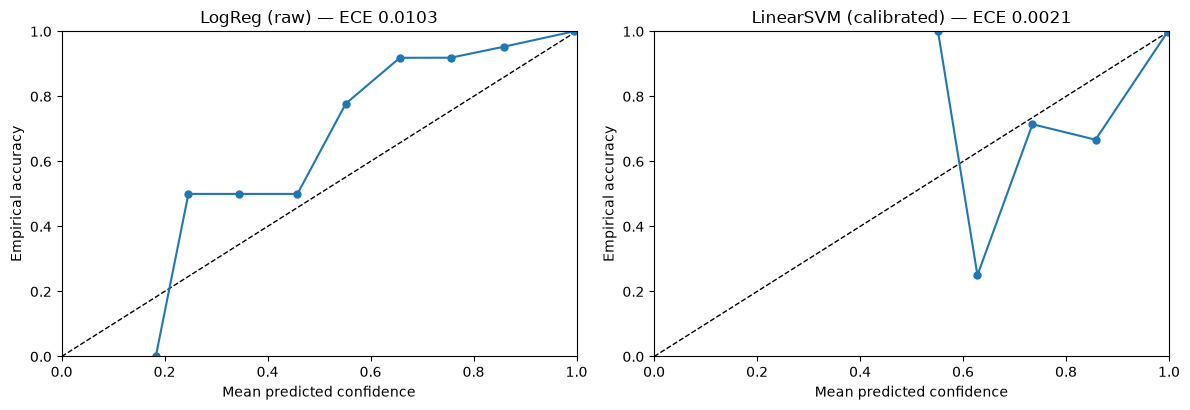

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (name, d) in zip(axes, [("LogReg (raw)", cal_lr), ("LinearSVM (calibrated)", cal_svc)]):
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.plot(d["calibration_curve"]["confidence"], d["calibration_curve"]["accuracy"], "o-", ms=5)
    ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
    ax.set_title(f"{name} — ECE {d['ece']:.4f}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

### 15.1 In-distribution calibration reference

The calibration experiment above uses the **random** split.  It is a
secondary reference only — it is **not** the final deployment calibration.
The final calibration lives entirely inside the merchant-disjoint regime
(§15.2), matching the primary evaluation benchmark.

### 15.2 Final calibration pipeline (merchant-disjoint regime)

The selected classifier family is LinearSVM (§11, best merchant-disjoint
Macro-F1).  A LinearSVM has no native probabilities, so the deployment model
is built **inside the merchant-disjoint development data**:

```
g_train / g_test   merchant-disjoint split (canonical overlap = 0)
g_fit  / g_cal     stratified 80/20 split of g_train
g_fit             TF-IDF fitting + LinearSVC training
g_cal             sigmoid calibration + confidence-threshold selection
g_test            final untouched evaluation
```

**Protocol** — the final merchant-disjoint test set is never used for model,
vectorizer, calibration, or threshold selection.  Merchant overlap between
g_fit and g_cal is permitted (forcing it would only shrink training data);
the hard requirement is **no test leakage**, verified below.  Representation:
word+char+direction (ablation winner; structural statistics omitted).

In [55]:
final_pipe = tx.final_merchant_disjoint_pipeline(df, seed=42)
print("Protocol partitions:")
for k, v in final_pipe["split_sizes"].items():
    print(f"  {k:6s} {v:>7,}")
print("Merchant overlap audit (must be 0 except g_fit x g_cal, which is allowed):")
print(json.dumps(final_pipe["merchant_overlap"], indent=2))
print(f"Representation: {final_pipe['representation']}")
print(f"Classifier: {final_pipe['classifier']} | Calibration: {final_pipe['calibration_method']}")

Protocol partitions:
  g_train  52,686
  g_fit   42,148
  g_cal   10,538
  g_test  15,314
Merchant overlap audit (must be 0 except g_fit x g_cal, which is allowed):
{
  "g_fit_x_g_cal": 2541,
  "g_fit_x_g_test": 0,
  "g_cal_x_g_test": 0,
  "canonical_g_train_x_g_test": 0
}
Representation: word+char+direction (ablation winner; structural omitted)
Classifier: LinearSVC | Calibration: sigmoid (Platt) via CalibratedClassifierCV(FrozenEstimator(base))


In [56]:
# final calibration metrics (probability quality on the untouched g_test)
from sklearn.metrics import log_loss
probs = final_pipe["test_proba"]
y_int = final_pipe["y_test_int"]
labels_all = list(range(len(final_pipe["classes_"])))
pred = probs.argmax(axis=1)
print("Final calibrated model — probability quality on g_test:")
print(f"  log-loss : {log_loss(y_int, probs, labels=labels_all):.4f}")
print(f"  Brier    : {tx.multiclass_brier(y_int, probs):.4f}")
print(f"  ECE      : {tx.expected_calibration_error(y_int, probs, n_bins=10):.4f}")
print(f"  Accuracy : {(pred == y_int).mean():.4f}  |  Macro-F1: "
      f"{__import__('sklearn.metrics', fromlist=['f1_score']).f1_score(y_int, pred, average='macro', zero_division=0):.4f}")

Final calibrated model — probability quality on g_test:
  log-loss : 0.2549
  Brier    : 0.0844
  ECE      : 0.0307
  Accuracy : 0.9530  |  Macro-F1: 0.9563


In [57]:
# threshold selected on g_cal (predefined rule), frozen, then evaluated once on g_test
sel_final = final_pipe["threshold_selection"]
print("Threshold selection (g_cal only):")
print("  selected:", sel_final["selected_threshold"], "|", sel_final["selection_objective"])
print("  calibration-slice table:")
print(pd.DataFrame(sel_final["calibration_slice_table"]).T.round(4).to_string())
print()
print("FROZEN threshold on g_test (final untouched evaluation):")
print(json.dumps(sel_final["frozen_threshold_test"], indent=2))

Threshold selection (g_cal only):
  selected: 0.99 | max Macro-F1 subject to coverage >= 0.9 (calibration slice)
  calibration-slice table:
      threshold  coverage  abstention_rate  accuracy  macro_f1  accepted_count
0.5        0.50    1.0000           0.0000    0.9989    0.9989         10538.0
0.6        0.60    0.9988           0.0012    0.9991    0.9992         10525.0
0.7        0.70    0.9985           0.0015    0.9992    0.9992         10522.0
0.8        0.80    0.9980           0.0020    0.9994    0.9994         10517.0
0.9        0.90    0.9973           0.0027    0.9995    0.9995         10510.0
0.95       0.95    0.9953           0.0047    0.9996    0.9996         10488.0
0.99       0.99    0.9764           0.0236    0.9999    0.9999         10289.0

FROZEN threshold on g_test (final untouched evaluation):
{
  "threshold": 0.99,
  "coverage": 0.7796,
  "abstention_rate": 0.2204,
  "accuracy": 0.9964,
  "macro_f1": 0.9964,
  "accepted_count": 11939
}


In [58]:
# final classification metrics on g_test (deployment-style)
final_md = tx.evaluate_model(
    final_pipe["model"], final_pipe["X_test"], final_pipe["g_test"]["category"].values,
    final_pipe["labels"], "final merchant-disjoint calibrated LinearSVM",
)
print("Final deployment-style results (g_test):")
print(f"  Accuracy {final_md['accuracy']} | Macro-F1 {final_md['macro_f1']} | "
      f"Weighted-F1 {final_md['weighted_f1']}")
print("  per-class F1:")
per_class_final = {
    k: v for k, v in final_md["classification_report"].items()
    if k not in ("accuracy", "macro avg", "weighted avg")
}
print(pd.DataFrame(per_class_final).T[["precision", "recall", "f1-score", "support"]]
      .sort_values("f1-score").round(4).to_string())

2026-08-19 06:12:28 | INFO     | final merchant-disjoint calibrated LinearSVM — Acc 0.9530  Macro-F1 0.9563  W-F1 0.9531


Final deployment-style results (g_test):
  Accuracy 0.953 | Macro-F1 0.9563 | Weighted-F1 0.9531
  per-class F1:
                precision  recall  f1-score  support
Transfer           0.6206  0.9276    0.7437    774.0
Fees               1.0000  0.6654    0.7991   1336.0
Groceries          0.9979  0.8462    0.9158   1099.0
Restaurants        0.9014  0.9988    0.9476    842.0
Insurance          0.9015  1.0000    0.9482    741.0
Shopping           0.9458  0.9729    0.9592    700.0
Subscription       0.9690  0.9732    0.9711    932.0
Utilities          0.9807  1.0000    0.9902    863.0
Income             0.9815  1.0000    0.9907    585.0
Healthcare         0.9887  0.9962    0.9924    787.0
Personal Care      0.9993  1.0000    0.9996   1364.0
Entertainment      1.0000  1.0000    1.0000   1085.0
Mortgage           1.0000  1.0000    1.0000    851.0
Rent               1.0000  1.0000    1.0000    716.0
Transportation     1.0000  1.0000    1.0000    635.0
Education          1.0000  1.0000    1.

## 16. Selective Prediction / Abstention

**Objective** — can confidence-aware abstention increase reliability, and at
what coverage cost?

**Method** — confidence = max probability of the **final calibrated model**
(§15.2 — calibrated inside the merchant-disjoint development data).  Report
coverage, abstention rate, accuracy and Macro-F1 among accepted items for
thresholds {0.5 … 0.99}.  The operating threshold was **selected on g_cal**
(max Macro-F1 subject to coverage ≥ 90%) and is frozen; the test evaluation
below is the untouched g_test.

In [59]:
sel_rows = pd.DataFrame(tx.abstention_table(final_pipe["test_proba"], final_pipe["y_test_int"])).T.reset_index(drop=True)
sel_rows = sel_rows[["threshold", "coverage", "abstention_rate", "accuracy", "macro_f1", "accepted_count"]]
sel_rows

,threshold,coverage,abstention_rate,accuracy,macro_f1,accepted_count
0,0.50,0.9952,0.0048,0.9575,0.9610,15240.0
1,0.60,0.9938,0.0062,0.9583,0.9619,15219.0
2,0.70,0.9910,0.0090,0.9589,0.9624,15176.0
3,0.80,0.9871,0.0129,0.9603,0.9635,15117.0
4,0.90,0.9596,0.0404,0.9687,0.9689,14696.0
5,0.95,0.9307,0.0693,0.9737,0.9724,14253.0
6,0.99,0.7796,0.2204,0.9964,0.9964,11939.0


In [60]:
sel2 = sel_final   # threshold already selected on g_cal in §15.2 (frozen)
print("Selected threshold:", sel2["selected_threshold"])
print("Objective:", sel2["selection_objective"])
print("Frozen-threshold TEST evaluation (g_test, untouched):", sel2["frozen_threshold_test"])

Selected threshold: 0.99
Objective: max Macro-F1 subject to coverage >= 0.9 (calibration slice)
Frozen-threshold TEST evaluation (g_test, untouched): {'threshold': 0.99, 'coverage': 0.7796, 'abstention_rate': 0.2204, 'accuracy': 0.9964, 'macro_f1': 0.9964, 'accepted_count': 11939}


In [61]:
tx.write_json({"classifier": final_pipe["classifier"],
                   "representation": final_pipe["representation"],
                   "calibration_source": "merchant-disjoint g_cal",
                   "rows": tx.abstention_table(final_pipe["test_proba"], final_pipe["y_test_int"]),
                   "threshold_selection": sel2},
                  Path("out") / "selective_prediction.json")
print("saved out/selective_prediction.json")

saved out/selective_prediction.json


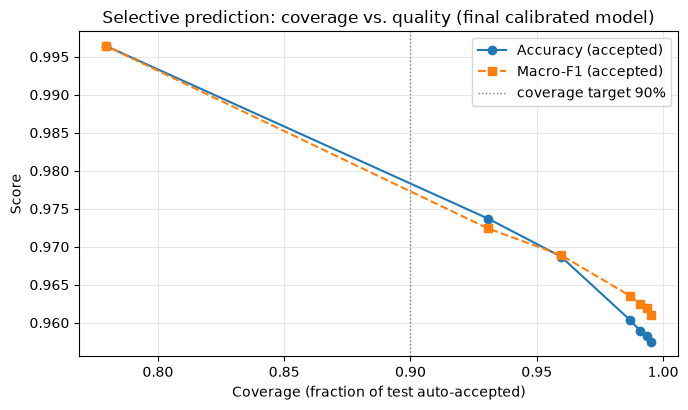

In [62]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(sel_rows["coverage"], sel_rows["accuracy"], "o-", label="Accuracy (accepted)")
ax.plot(sel_rows["coverage"], sel_rows["macro_f1"], "s--", label="Macro-F1 (accepted)")
ax.axvline(sel2["coverage_target"], color="grey", ls=":", lw=1, label=f"coverage target {sel2['coverage_target']:.0%}")
ax.set_xlabel("Coverage (fraction of test auto-accepted)")
ax.set_ylabel("Score")
ax.set_title("Selective prediction: coverage vs. quality (final calibrated model)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 17. Learning Curve

**Objective** — is the project data-limited?  Does more labeled data help?

**Method** — fixed test set; training sizes 5K / 10K / 20K / 40K / full.
Same preprocessing, same model, same hyperparameters, same test set (no
per-size tuning).

**Result** — training size vs Macro-F1.

In [63]:
lc = tx.learning_curve(df, train_sizes=(5_000, 10_000, 20_000, 40_000), seed=42)
lc_rows = pd.DataFrame(lc["rows"])
lc_rows

2026-08-19 06:12:29 | INFO     | learning_curve::5000 — Acc 0.9144  Macro-F1 0.9143  W-F1 0.9143


2026-08-19 06:12:30 | INFO     | learning_curve::10000 — Acc 0.9599  Macro-F1 0.9599  W-F1 0.9599


2026-08-19 06:12:31 | INFO     | learning_curve::20000 — Acc 0.9831  Macro-F1 0.9831  W-F1 0.9831


2026-08-19 06:12:35 | INFO     | learning_curve::40000 — Acc 0.9924  Macro-F1 0.9924  W-F1 0.9924


,train_size,accuracy,macro_f1
0,5000,0.9144,0.9143
1,10000,0.9599,0.9599
2,20000,0.9831,0.9831
3,40000,0.9924,0.9924


In [64]:
# add the full-train point from the random-split model
lc_rows.loc[len(lc_rows)] = {"train_size": len(train_df), "accuracy": hybrid_metrics["accuracy"], "macro_f1": hybrid_metrics["macro_f1"]}
tx.write_json({"rows": lc_rows.to_dict("records")}, Path("out") / "learning_curve.json")
print("saved out/learning_curve.json")

saved out/learning_curve.json


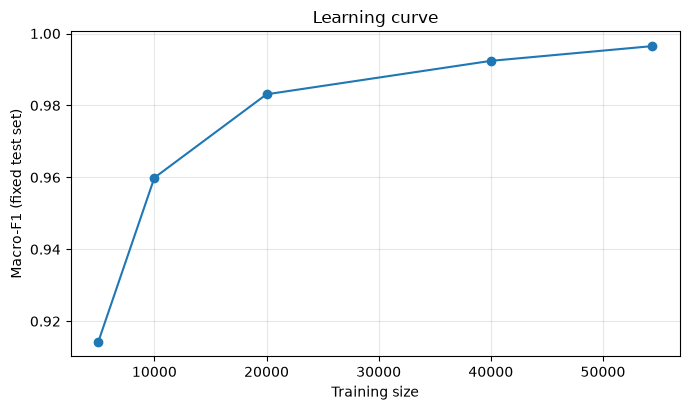

In [65]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(lc_rows["train_size"], lc_rows["macro_f1"], "o-")
ax.set_xlabel("Training size"); ax.set_ylabel("Macro-F1 (fixed test set)")
ax.set_title("Learning curve")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 18. Error Analysis

**Objective** — characterize the dominant failure modes of the final model.

**Method** — per-class F1 ranking (worst/best), confusion matrix, and
representative misclassifications with confidence, plus low-confidence
correct and high-confidence error examples.  All analysis uses the model
selected in §11 (best merchant-disjoint Macro-F1) on the merchant-disjoint
test set.

In [66]:
# final model = the calibrated merchant-disjoint deployment pipeline (§15.2)
print("Final model:", final_pipe["classifier"],
      f"(merchant-disjoint Macro-F1 {gen_metrics[final_family]['macro_f1']:.4f}) | "
      f"calibrated on g_cal | representation: {final_pipe['representation']}")

Final model: LinearSVC (merchant-disjoint Macro-F1 0.9588) | calibrated on g_cal | representation: word+char+direction (ablation winner; structural omitted)


In [67]:
final_pred = final_pipe["model"].predict(final_pipe["X_test"])
final_true = final_pipe["g_test"]["category"].values
labels_f = final_pipe["labels"]
final_macro = tx.evaluate_model(final_pipe["model"], final_pipe["X_test"], final_true,
                                labels_f, "final calibrated")["classification_report"]["macro avg"]
print("Final-model test metrics (g_test):", {k: round(final_macro[k], 4) for k in ("precision", "recall", "f1-score")})

2026-08-19 06:12:35 | INFO     | final calibrated — Acc 0.9530  Macro-F1 0.9563  W-F1 0.9531


Final-model test metrics (g_test): {'precision': 0.958, 'recall': 0.9635, 'f1-score': 0.9563}


In [68]:
per_class = {
    k: v for k, v in tx.evaluate_model(final_pipe["model"], final_pipe["X_test"], final_true,
                                       labels_f, "final")["classification_report"].items()
    if k not in ("accuracy", "macro avg", "weighted avg")
}
per_class_df = pd.DataFrame(per_class).T[["precision", "recall", "f1-score", "support"]].sort_values("f1-score")
print("Worst 5 categories:")
print(per_class_df.head(5).to_string())
print()
print("Best 5 categories:")
print(per_class_df.tail(5).to_string())

2026-08-19 06:12:35 | INFO     | final — Acc 0.9530  Macro-F1 0.9563  W-F1 0.9531


Worst 5 categories:
             precision    recall  f1-score  support
Transfer      0.620570  0.927649  0.743656    774.0
Fees          1.000000  0.665419  0.799101   1336.0
Groceries     0.997854  0.846224  0.915805   1099.0
Restaurants   0.901393  0.998812  0.947606    842.0
Insurance     0.901460  1.000000  0.948177    741.0

Best 5 categories:
                precision  recall  f1-score  support
Mortgage              1.0     1.0       1.0    851.0
Rent                  1.0     1.0       1.0    716.0
Transportation        1.0     1.0       1.0    635.0
Education             1.0     1.0       1.0   1168.0
Travel                1.0     1.0       1.0    836.0


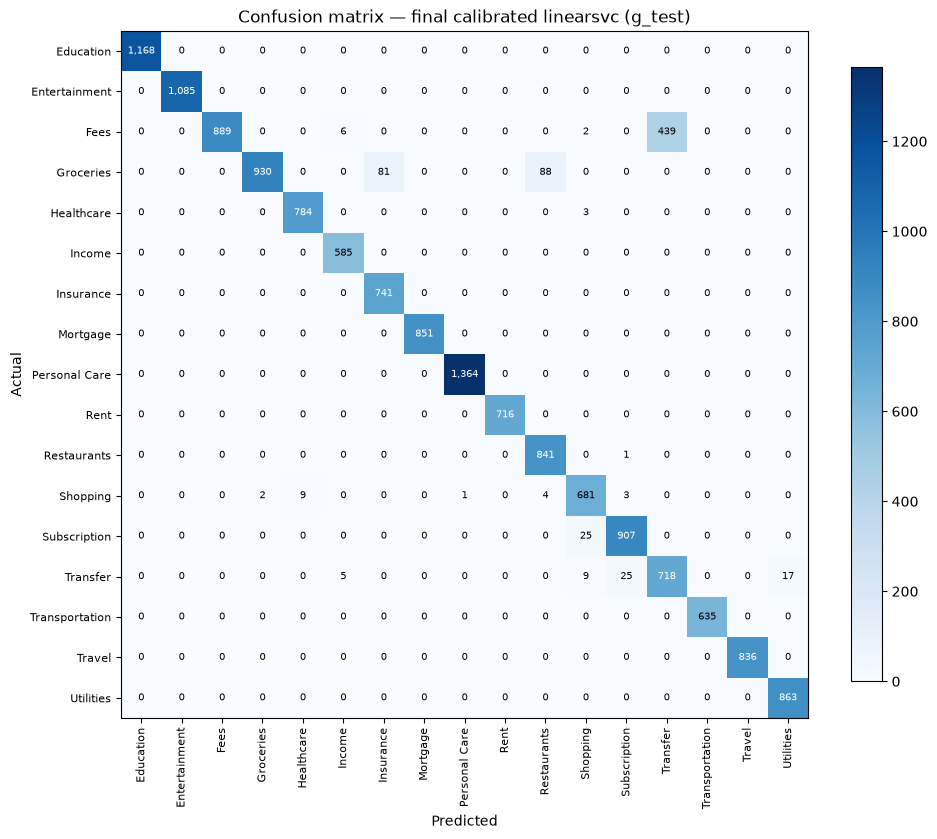

In [69]:
from sklearn.metrics import confusion_matrix
import itertools

cm = confusion_matrix(final_true, final_pred, labels=labels_f)
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_f))); ax.set_yticks(range(len(labels_f)))
ax.set_xticklabels(labels_f, rotation=90, fontsize=8)
ax.set_yticklabels(labels_f, fontsize=8)
thr = cm.max() / 2
for i, j in itertools.product(range(len(labels_f)), range(len(labels_f))):
    ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
            fontsize=7, color="white" if cm[i, j] > thr else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — final calibrated {final_family} (g_test)")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()

In [70]:
er = tx.error_analysis(
    df,
    seed=42,
    prefit={
        "model":   final_pipe["model"],
        "X_test":  final_pipe["X_test"],
        "test_df": final_pipe["g_test"],
        "labels":  labels_f,
    },
)
print("Misclassification rate (final calibrated model, g_test):", er["misclassification_rate"])
err_df = pd.DataFrame(er["examples"])[["true", "predicted", "description", "confidence"]]
err_df.head(25)

Misclassification rate (final calibrated model, g_test): 0.047


,true,predicted,description,confidence
0,Subscription,Shopping,[debit] EXPRESSVPN,0.9919
1,Fees,Transfer,[debit] atm surcharge,0.9893
2,Fees,Transfer,[debit] DAILY CASH ADJUSTMENT,0.8568
3,Fees,Transfer,[debit] ATM SURCHARGE,0.9893
4,Fees,Transfer,[debit] ATM SERVICE CHARGE - 09/11,0.9609
5,Groceries,Insurance,[debit] SQ *FARM STAND,0.4851
6,Fees,Transfer,[debit] ATM SERVICE CHARGE,0.9862
7,Transfer,Shopping,[credit] PAYPAL INST XFER AMEX AUTOPAY WEB ID:...,0.3343
8,Fees,Transfer,[debit] ATM SURCHARGE,0.9893
9,Fees,Transfer,[debit] ATM SERVICE CHARGE - 48/72,0.9458


In [71]:
# confidence analysis — the final calibrated SVM HAS probabilities
# (spec §10): high-confidence errors (conf >= 0.95) and low-confidence
# correct predictions (conf below the SELECTED threshold from g_cal)
_probs = final_pipe["test_proba"]
_conf = _probs.max(axis=1)
_pred = _probs.argmax(axis=1)
_true = final_pipe["y_test_int"]
_descs = final_pipe["g_test"]["description"].to_numpy()
_sel_t = sel_final["selected_threshold"]
highc_error = np.where((_conf >= 0.95) & (_pred != _true))[0]
lowc_correct = np.where((_conf < _sel_t) & (_pred == _true))[0]
print(f"high-confidence errors (conf>=0.95): {len(highc_error)} | "
      f"low-confidence correct (conf < {_sel_t}): {len(lowc_correct)}")
print()
print("High-confidence errors (True | Predicted | Confidence | Description):")
for i in highc_error[:8]:
    print(f"  {labels_f[_true[i]]:12s} -> {labels_f[_pred[i]]:12s} {_conf[i]:.3f}  {_descs[i][:70]}")
print()
print("Low-confidence correct (True | Confidence | Description):")
for i in lowc_correct[:5]:
    print(f"  {labels_f[_true[i]]:12s} {_conf[i]:.3f}  {_descs[i][:70]}")

high-confidence errors (conf>=0.95): 375 | low-confidence correct (conf < 0.99): 2698

High-confidence errors (True | Predicted | Confidence | Description):
  Fees         -> Transfer     0.975  [credit] ATM SERVICE CHARGE
  Groceries    -> Restaurants  0.997  [debit] SQ *GREEN VALLEY
  Groceries    -> Restaurants  0.997  [debit] SQ *GREEN VALLEY
  Fees         -> Transfer     0.968  [debit] ATM SURCHARGE - 93/29
  Fees         -> Transfer     0.986  [debit] ATM SERVICE CHARGE
  Fees         -> Transfer     0.986  [debit] ATM SERVICE CHARGE
  Fees         -> Transfer     0.989  [debit] ATM SURCHARGE
  Fees         -> Transfer     0.954  [debit] ATM SERVICE CHARGE - 67/52

Low-confidence correct (True | Confidence | Description):
  Groceries    0.987  [debit] PUBLIX 7860 UNIVERSITY LN OAKLAND 94601-4574CA USA
  Subscription 0.985  [debit] Subscription Payment: BASECAMP
  Income       0.884  [credit] SALESFORCE PAYROLL
  Subscription 0.987  [debit] PAYPAL INST XFER ZENDESK WEB ID: PAYPAL

In [72]:
tx.write_json(er, Path("out") / "error_analysis.json")
print("saved out/error_analysis.json")

saved out/error_analysis.json


## 19. Final Model Selection

**Selection rule (spec)** — primary criterion: **merchant-disjoint Macro-F1**;
secondary: standard Macro-F1, calibration quality, inference complexity.
Random-split accuracy is an in-distribution reference, not the selector.

**Method** — the final comparison runs all three classifiers under all three
regimes (random / merchant-disjoint / strict) with identical representations
and hyperparameters.  The per-class table exposes the weakest classes.

In [73]:
final_comp = tx.final_comparison(df, seed=42)
final_df = pd.DataFrame(final_comp).T[["random_macro_f1", "merchant_disjoint_macro_f1", "strict_macro_f1"]]
final_df.columns = ["Random Macro-F1", "Merchant-Disjoint Macro-F1", "Strict Macro-F1"]
final_df["Model"] = ["Logistic Regression", "Linear SVM", "XGBoost"]
final_df = final_df[["Model", "Random Macro-F1", "Merchant-Disjoint Macro-F1", "Strict Macro-F1"]].round(4)
final_df

2026-08-19 06:12:49 | INFO     | logreg · hybrid — Acc 0.9967  Macro-F1 0.9967  W-F1 0.9967


2026-08-19 06:13:04 | INFO     | logreg · hybrid — Acc 0.9477  Macro-F1 0.9516  W-F1 0.9482


2026-08-19 06:13:19 | INFO     | logreg · hybrid — Acc 0.9477  Macro-F1 0.9516  W-F1 0.9482


2026-08-19 06:13:19 | INFO     | final comparison logreg: random 0.9967 | merchant-disjoint 0.9516 | strict 0.9516


2026-08-19 06:13:50 | INFO     | linearsvc · hybrid — Acc 0.9988  Macro-F1 0.9987  W-F1 0.9987


...

2026-08-19 06:25:58 | INFO     | xgboost · hybrid — Acc 0.9880  Macro-F1 0.9879  W-F1 0.9879


2026-08-19 06:36:22 | INFO     | xgboost · hybrid — Acc 0.8691  Macro-F1 0.8661  W-F1 0.8704


2026-08-19 06:46:46 | INFO     | xgboost · hybrid — Acc 0.8691  Macro-F1 0.8661  W-F1 0.8704


2026-08-19 06:46:46 | INFO     | final comparison xgboost: random 0.9879 | merchant-disjoint 0.8661 | strict 0.8661


,Model,Random Macro-F1,Merchant-Disjoint Macro-F1,Strict Macro-F1
logreg,Logistic Regression,0.9967,0.9516,0.9516
linearsvc,Linear SVM,0.9987,0.9588,0.9588
xgboost,XGBoost,0.9879,0.8661,0.8661


In [74]:
tx.write_json(final_comp, Path("out") / "final_comparison.json")
print("saved out/final_comparison.json")

saved out/final_comparison.json


In [75]:
# selection: best by merchant-disjoint Macro-F1 (frozen before final reporting)
selected = max(final_comp, key=lambda m: final_comp[m]["merchant_disjoint_macro_f1"])
print(f"FINAL MODEL: {selected}  (merchant-disjoint Macro-F1 {final_comp[selected]['merchant_disjoint_macro_f1']:.4f})")
print(f"  random split Macro-F1: {final_comp[selected]['random_macro_f1']:.4f}")
print(f"  strict benchmark Macro-F1: {final_comp[selected]['strict_macro_f1']:.4f}")
print("  deployed as: LinearSVM -> CalibratedClassifierCV(sigmoid), calibrated on g_cal [§15.2]")

FINAL MODEL: linearsvc  (merchant-disjoint Macro-F1 0.9588)
  random split Macro-F1: 0.9987
  strict benchmark Macro-F1: 0.9588
  deployed as: LinearSVM -> CalibratedClassifierCV(sigmoid), calibrated on g_cal [§15.2]


### 19.0 Strict benchmark — frozen pipeline evaluation

The strict merchant + exact-description-disjoint test is a held-out
robustness test.  The **already-frozen** final calibrated model and threshold
are applied to it — nothing is retuned.

In [76]:
strict_frozen = tx.strict_frozen_evaluation(df, final_pipe, seed=42)
print(json.dumps({k: v for k, v in strict_frozen.items() if k != "note"}, indent=2))
assert strict_frozen["merchant_overlap"] == 0
assert strict_frozen["exact_desc_overlap"] == 0
print("assertions passed: strict merchant overlap = 0, exact-description overlap = 0")

{
  "merchant_overlap": 0,
  "exact_desc_overlap": 0,
  "train_size_strict": 52686,
  "test_size_strict": 15314,
  "accuracy": 0.953,
  "macro_f1": 0.9563,
  "weighted_f1": 0.9531,
  "log_loss": 0.2549,
  "brier": 0.0844,
  "ece": 0.0307,
  "selective": {
    "frozen_threshold": 0.99,
    "coverage": 0.7796,
    "abstention_rate": 0.2204,
    "accuracy_accepted": 0.9964,
    "macro_f1_accepted": 0.9964
  }
}
assertions passed: strict merchant overlap = 0, exact-description overlap = 0


### 19.3 Final results tables (programmatic)

The final selected classifier is **Linear SVM** (calibrated on g_cal).  Its
Macro-F1 / accuracy / weighted-F1 under each regime, and the frozen-threshold
selective-prediction summary on the untouched g_test.

In [77]:
fc = final_comp[selected]
regime_table = pd.DataFrame([
    {"Evaluation Regime": "Random reference (in-distribution)",
     "Model": "Linear SVM", "Macro-F1": fc["random_macro_f1"],
     "Accuracy": fc["random_accuracy"], "Weighted-F1": fc["random_weighted_f1"]},
    {"Evaluation Regime": "Merchant-disjoint (primary)",
     "Model": "Linear SVM", "Macro-F1": fc["merchant_disjoint_macro_f1"],
     "Accuracy": fc["merchant_disjoint_accuracy"], "Weighted-F1": fc["merchant_disjoint_weighted_f1"]},
    {"Evaluation Regime": "Strict (merchant + description disjoint)",
     "Model": "Linear SVM", "Macro-F1": strict_frozen["macro_f1"],
     "Accuracy": strict_frozen["accuracy"], "Weighted-F1": strict_frozen["weighted_f1"]},
]).round(4)
regime_table

,Evaluation Regime,Model,Macro-F1,Accuracy,Weighted-F1
0,Random reference (in-distribution),Linear SVM,0.9987,0.9988,0.9987
1,Merchant-disjoint (primary),Linear SVM,0.9588,0.9547,0.9550
2,Strict (merchant + description disjoint),Linear SVM,0.9563,0.9530,0.9531


In [78]:
thr_rows = []
for t, r in tx.abstention_table(final_pipe["test_proba"], final_pipe["y_test_int"]).items():
    thr_rows.append({"Threshold": r["threshold"], "Calibration Source": "g_cal",
                     "Test Coverage": r["coverage"], "Test Accuracy": r["accuracy"],
                     "Test Macro-F1": r["macro_f1"]})
thr_df = pd.DataFrame(thr_rows).round(4)
thr_df["← selected"] = thr_df["Threshold"] == sel_final["selected_threshold"]
thr_df

,Threshold,Calibration Source,Test Coverage,Test Accuracy,Test Macro-F1,← selected
0,0.50,g_cal,0.9952,0.9575,0.9610,False
1,0.60,g_cal,0.9938,0.9583,0.9619,False
2,0.70,g_cal,0.9910,0.9589,0.9624,False
3,0.80,g_cal,0.9871,0.9603,0.9635,False
4,0.90,g_cal,0.9596,0.9687,0.9689,False
5,0.95,g_cal,0.9307,0.9737,0.9724,False
6,0.99,g_cal,0.7796,0.9964,0.9964,True


In [79]:
tx.write_json(final_comp, Path("out") / "final_comparison.json")
tx.write_json(regime_table.to_dict("records"), Path("out") / "final_regime_table.json")
tx.write_json(thr_df.to_dict("records"), Path("out") / "final_threshold_table.json")
tx.write_json(strict_frozen, Path("out") / "strict_frozen_evaluation.json")
print("saved final comparison, regime table, threshold table, strict evaluation")

saved final comparison, regime table, threshold table, strict evaluation


### 19.1 Per-class analysis (merchant-disjoint test)

Five strongest and five weakest classes under unseen-merchant evaluation —
poor classes are not hidden behind weighted averages.

In [80]:
final_pc = pd.DataFrame(gen_metrics[final_family]["classification_report"]).T
final_pc = final_pc[["precision", "recall", "f1-score", "support"]].drop(
    index=["accuracy", "macro avg", "weighted avg"]).sort_values("f1-score")
print("Weakest 5 (unseen merchants):")
print(final_pc.head(5).round(4).to_string())
print()
print("Strongest 5 (unseen merchants):")
print(final_pc.tail(5).round(4).to_string())

Weakest 5 (unseen merchants):
             precision  recall  f1-score  support
Transfer        0.6181  0.9367    0.7447    774.0
Fees            1.0000  0.6654    0.7991   1336.0
Groceries       0.9979  0.8462    0.9158   1099.0
Restaurants     0.8618  1.0000    0.9258    842.0
Insurance       0.9512  1.0000    0.9750    741.0

Strongest 5 (unseen merchants):
                precision  recall  f1-score  support
Mortgage              1.0     1.0       1.0    851.0
Rent                  1.0     1.0       1.0    716.0
Transportation        1.0     1.0       1.0    635.0
Education             1.0     1.0       1.0   1168.0
Travel                1.0     1.0       1.0    836.0


### 19.2 Generalization summary

The central scientific result — Macro-F1 under each evaluation regime.

In [81]:
fmt_best = max((r["macro_f1"] for r in fmt_eval.values() if not r.get("skipped")), default=float("nan"))
gen_summary = pd.DataFrame({
    "Evaluation regime": [
        "Random (in-distribution)",
        "Merchant-disjoint (unseen merchant)",
        "Format-disjoint (unseen format, best)",
        "Merchant + description disjoint (strict)",
    ],
    "Purpose": [
        "in-distribution benchmark (merchant overlap possible)",
        "unseen-merchant generalization",
        "unseen-format generalization",
        "strict lexical generalization",
    ],
    "Best Macro-F1": [
        max(m["random_macro_f1"] for m in final_comp.values()),
        max(m["merchant_disjoint_macro_f1"] for m in final_comp.values()),
        round(fmt_best, 4),
        max(m["strict_macro_f1"] for m in final_comp.values()),
    ],
})
gen_summary

,Evaluation regime,Purpose,Best Macro-F1
0,Random (in-distribution),in-distribution benchmark (merchant overlap po...,0.9987
1,Merchant-disjoint (unseen merchant),unseen-merchant generalization,0.9588
2,"Format-disjoint (unseen format, best)",unseen-format generalization,0.6983
3,Merchant + description disjoint (strict),strict lexical generalization,0.9588


In [82]:
tx.write_json(gen_summary.to_dict("records"), Path("out") / "generalization_summary.json")
print("saved out/generalization_summary.json")

saved out/generalization_summary.json


## 20. Conclusions

Every conclusion below is generated from executed metrics.  The dataset is a
**controlled synthetic transaction-classification benchmark** with realistic
bank-statement formatting; results do not estimate bank-production
performance.

The central message:

> Random splits can overestimate generalization because transaction data
> contain repeated merchants, descriptions, IDs and formatting patterns.
> Merchant-disjoint and strict description-disjoint evaluations test whether
> the model learns transferable transaction language.

In [83]:
print("=" * 74)
print("CONCLUSIONS (from executed values)")
print("=" * 74)
print(f"[1]  Random splitting overestimates generalization: the random test has "
      f"{gen_out['random_split_merchant_overlap_fraction']:.1%} merchant overlap with train "
      f"and {dup_audit_random['random_split_test_desc_share_seen_in_train']:.1%} of its exact "
      f"descriptions appear in train — repeated merchants/descriptions make the in-distribution "
      f"benchmark artificially easy (Macro-F1 {max(m['random_macro_f1'] for m in final_comp.values()):.4f}).")
print(f"[2]  Merchant-disjoint evaluation is therefore the PRIMARY generalization benchmark "
      f"(best Macro-F1 {max(m['merchant_disjoint_macro_f1'] for m in final_comp.values()):.4f}).")
print(f"[3]  Linear SVM remains the best classifier under unseen-merchant evaluation "
      f"({final_comp['linearsvc']['merchant_disjoint_macro_f1']:.4f} vs "
      f"logreg {final_comp['logreg']['merchant_disjoint_macro_f1']:.4f}, "
      f"xgboost {final_comp['xgboost']['merchant_disjoint_macro_f1']:.4f}).")
print(f"[4]  Strict merchant + exact-description-disjoint tests whether exact duplicates explain "
      f"the result: Macro-F1 {strict_frozen['macro_f1']:.4f} with train retained "
      f"{strict_info['train_share_retained']:.0%} — duplicates never span merchants here, so strict "
      f"equals merchant-disjoint (no evidence that exact duplicates drive the score).")
print(f"[5]  Calibration and selective prediction are fitted and selected ENTIRELY inside the "
      f"merchant-disjoint development data (g_fit/g_cal): threshold "
      f"{sel_final['selected_threshold']:.2f} chosen on g_cal (max Macro-F1, coverage ≥ "
      f"{sel_final['coverage_target']:.0%}).")
print(f"[6]  The final test result is therefore genuinely untouched: on g_test, "
      f"Accuracy {final_md['accuracy']}, Macro-F1 {final_md['macro_f1']}, "
      f"frozen-threshold coverage {sel_final['frozen_threshold_test']['coverage']:.4f} at "
      f"accuracy {sel_final['frozen_threshold_test']['accuracy']:.4f}.")
print()
print("This is a controlled SYNTHETIC transaction-classification benchmark with realistic "
      "bank-statement formatting; results do not estimate real-bank production performance.")
print("=" * 74)

CONCLUSIONS (from executed values)
[1]  Random splitting overestimates generalization: the random test has 87.7% merchant overlap with train and 24.5% of its exact descriptions appear in train — repeated merchants/descriptions make the in-distribution benchmark artificially easy (Macro-F1 0.9987).
[2]  Merchant-disjoint evaluation is therefore the PRIMARY generalization benchmark (best Macro-F1 0.9588).
[3]  Linear SVM remains the best classifier under unseen-merchant evaluation (0.9588 vs logreg 0.9516, xgboost 0.8661).
[4]  Strict merchant + exact-description-disjoint tests whether exact duplicates explain the result: Macro-F1 0.9563 with train retained 100% — duplicates never span merchants here, so strict equals merchant-disjoint (no evidence that exact duplicates drive the score).
[5]  Calibration and selective prediction are fitted and selected ENTIRELY inside the merchant-disjoint development data (g_fit/g_cal): threshold 0.99 chosen on g_cal (max Macro-F1, coverage ≥ 90%).
[6] 

## 21. Reproducibility

**Configuration** — `RANDOM_STATE = 42` throughout; TF-IDF fit on train only;
calibration and threshold selection on a held-out slice (never test); fixed
test set for learning curves; identical representations and hyperparameters
across regimes.

**Artifacts** — all JSON files below are generated by this notebook; no metric
is hand-entered.

In [84]:
final_results = {
    "random_state": 42,
    "dataset": {"rows": int(len(df)), "categories": int(df["category"].nunique()),
                "merchants": int(df["merchant"].nunique())},
    "splits": {
        "random": {"train": int(len(train_df)), "test": int(len(test_df))},
        "merchant_disjoint": {"train": int(len(g_train)), "test": int(len(g_test)),
                              "merchant_overlap": int(split_info["merchant_overlap"])},
        "strict": {"train": int(len(s_train)), "test": int(len(s_test)),
                   "merchant_overlap": int(strict_info["merchant_overlap"]),
                   "exact_desc_overlap": int(strict_info["exact_desc_overlap"]),
                   "train_share_retained": strict_info["train_share_retained"]},
    },
    "representation": "word+char+direction (ablation winner; structural omitted)",
    "selected_model": selected,
    "deployment_pipeline": f"{selected} -> CalibratedClassifierCV(sigmoid)",
    "deployment_calibration": {"g_fit": final_pipe["split_sizes"]["g_fit"],
                               "g_cal": final_pipe["split_sizes"]["g_cal"],
                               "g_test": final_pipe["split_sizes"]["g_test"]},
    "final_macro_f1": {
        "random": final_comp[selected]["random_macro_f1"],
        "merchant_disjoint": final_comp[selected]["merchant_disjoint_macro_f1"],
        "strict": final_comp[selected]["strict_macro_f1"],
    },
    "calibration_ece": {"logreg": cal_lr["ece"], "linearsvc": cal_svc["ece"]},
    "abstention_threshold": sel2["selected_threshold"],
    "learning_curve": lc_rows.to_dict("records"),
}
tx.write_json(final_results, Path("out") / "final_results.json")
print("saved out/final_results.json")

saved out/final_results.json


In [85]:
# spec-mandated final artifacts: model config, calibration, selective, generalization
from sklearn.metrics import log_loss as _log_loss
_probs = final_pipe["test_proba"]
_y_int = final_pipe["y_test_int"]
_all = list(range(len(final_pipe["classes_"])))
_pred = _probs.argmax(axis=1)
final_model_config = {
    "random_state": final_pipe["random_state"],
    "classifier": final_pipe["classifier"],
    "representation": final_pipe["representation"],
    "calibration": final_pipe["calibration_method"],
    "calibration_partition": "g_cal (merchant-disjoint development data)",
    "split_sizes": final_pipe["split_sizes"],
    "merchant_overlap_audit": final_pipe["merchant_overlap"],
    "threshold": sel_final["selected_threshold"],
    "threshold_objective": sel_final["selection_objective"],
}
tx.write_json(final_model_config, Path("out") / "final_model_config.json")

final_calibration_metrics = {
    "partition": "g_test (untouched)",
    "log_loss": round(float(_log_loss(_y_int, _probs, labels=_all)), 4),
    "brier": round(tx.multiclass_brier(_y_int, _probs), 4),
    "ece": round(tx.expected_calibration_error(_y_int, _probs, n_bins=10), 4),
    "accuracy": round(float((_pred == _y_int).mean()), 4),
    "macro_f1": round(float(__import__("sklearn.metrics", fromlist=["f1_score"])
                           .f1_score(_y_int, _pred, average="macro", zero_division=0)), 4),
    "weighted_f1": round(float(__import__("sklearn.metrics", fromlist=["f1_score"])
                               .f1_score(_y_int, _pred, average="weighted", zero_division=0)), 4),
}
tx.write_json(final_calibration_metrics, Path("out") / "final_calibration_metrics.json")

final_selective = {
    "calibration_source": "g_cal",
    "selected_threshold": sel_final["selected_threshold"],
    "frozen_threshold_test": sel_final["frozen_threshold_test"],
    "test_full_table": sel_final["test_full_table"],
}
tx.write_json(final_selective, Path("out") / "final_selective_prediction.json")

final_generalization = {
    "merchant_disjoint": {
        "macro_f1": final_comp[selected]["merchant_disjoint_macro_f1"],
        "accuracy": final_comp[selected]["merchant_disjoint_accuracy"],
        "weighted_f1": final_comp[selected]["merchant_disjoint_weighted_f1"],
        "canonical_merchant_overlap": int(final_pipe["merchant_overlap"]["canonical_g_train_x_g_test"]),
    },
    "strict": {k: v for k, v in strict_frozen.items() if k != "note"},
    "random_reference": {
        "macro_f1": final_comp[selected]["random_macro_f1"],
        "accuracy": final_comp[selected]["random_accuracy"],
        "weighted_f1": final_comp[selected]["random_weighted_f1"],
    },
}
tx.write_json(final_generalization, Path("out") / "final_generalization_metrics.json")
print("saved final_model_config / final_calibration_metrics / final_selective_prediction / final_generalization_metrics")

saved final_model_config / final_calibration_metrics / final_selective_prediction / final_generalization_metrics


In [86]:
# protocol summary (spec §11)
print("=" * 74)
print("FINAL PROTOCOL (merchant-disjoint regime)")
print("=" * 74)
print(f"  g_fit  {final_pipe['split_sizes']['g_fit']:>7,}   TF-IDF fitting + LinearSVC training")
print(f"  g_cal  {final_pipe['split_sizes']['g_cal']:>7,}   sigmoid calibration + threshold selection")
print(f"  g_test {final_pipe['split_sizes']['g_test']:>7,}   final untouched evaluation")
print(f"  merchant overlap g_fit x g_test : {final_pipe['merchant_overlap']['g_fit_x_g_test']} (must be 0)")
print(f"  merchant overlap g_cal x g_test : {final_pipe['merchant_overlap']['g_cal_x_g_test']} (must be 0)")
print("  The final merchant-disjoint test set is never used for model, vectorizer,")
print("  calibration, or threshold selection.")
print("=" * 74)

FINAL PROTOCOL (merchant-disjoint regime)
  g_fit   42,148   TF-IDF fitting + LinearSVC training
  g_cal   10,538   sigmoid calibration + threshold selection
  g_test  15,314   final untouched evaluation
  merchant overlap g_fit x g_test : 0 (must be 0)
  merchant overlap g_cal x g_test : 0 (must be 0)
  The final merchant-disjoint test set is never used for model, vectorizer,
  calibration, or threshold selection.


In [87]:
print("=" * 74)
print("REPRODUCIBILITY ARTIFACTS")
print("=" * 74)
for p in sorted(Path("out").glob("*.json")):
    print(f"  {p.name:34s} {p.stat().st_size:>8,} B")
print()
print(f"Final model: {selected} | representation: word+char+direction (ablation winner; structural omitted) | seed 42")
print(f"  random Macro-F1          = {final_comp[selected]['random_macro_f1']:.4f}")
print(f"  merchant-disjoint Macro-F1 = {final_comp[selected]['merchant_disjoint_macro_f1']:.4f}")
print(f"  strict Macro-F1          = {final_comp[selected]['strict_macro_f1']:.4f}")
print("=" * 74)

REPRODUCIBILITY ARTIFACTS
  calibration_metrics.json              2,442 B
  classification_metrics.json          19,587 B
  dataset_duplicate_audit.json            366 B
  dataset_summary.json                    766 B
  error_analysis.json                   5,166 B
  feature_ablation.json                   486 B
  final_calibration_metrics.json          165 B
  final_comparison.json                 1,020 B
  final_generalization_metrics.json       706 B
  final_model_config.json                 656 B
  final_regime_table.json                 518 B
  final_results.json                    1,427 B
  final_selective_prediction.json       1,576 B
  final_threshold_table.json            1,254 B
  format_generalization.json            2,199 B
  generalization_metrics.json          23,435 B
  generalization_summary.json             618 B
  learning_curve.json                     472 B
  merchant_ablation.json                  289 B
  selective_prediction.json             4,741 B
  strict_froze